<a href="https://colab.research.google.com/github/erickvaldezsallagos/PROCESOS-ESTOCASTICOS/blob/main/Descomposicioncanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESCOMPOSICION CANONICA**

**VALDEZ SALLAGOS ERICK**



*Escriba la matriz $P$ de la imagen anexa y dibuje su diagrama de transiciones*

In [48]:
import sympy as sp
from sympy import Rational, Matrix
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

**De la imagen, se tienen los estados:**

In [49]:
states = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

**Introduzcamos la Matriz $P$**

In [50]:
P = Matrix([
    [Rational(1,4), 0, 0, 0, 0, 0, Rational(3,4)],
    [Rational(1,8), Rational(1,8), Rational(1,4), 0, Rational(1,4), Rational(1,8), Rational(1,8)],
    [0, 0, Rational(2,5), Rational(1,5), Rational(2,5), 0, 0],
    [0, 0, Rational(1,2), Rational(1,2), 0, 0, 0],
    [0, 0, 0, Rational(1,2), Rational(1,2), 0, 0],
    [0, Rational(1,5), 0, Rational(1,5), Rational(1,5), Rational(1,5), Rational(1,5)],
    [Rational(4,5), 0, 0, 0, 0, 0, Rational(1,5)]
])

# Mostramos la matriz
print("Matriz de Transición P:")
display(P)

Matriz de Transición P:


Matrix([
[1/4,   0,   0,   0,   0,   0, 3/4],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
[4/5,   0,   0,   0,   0,   0, 1/5]])

**De lo anterior, verifiquemos las propiedades vistas en clase, de las cuales las clasificaremos**

In [51]:
G = nx.DiGraph()

for state in states:
    G.add_node(state)


for i, origin in enumerate(states):
    for j, dest in enumerate(states):
        prob = P[i, j]
        if prob > 0:

            G.add_edge(origin, dest, weight=prob)

In [52]:
# Nota: scc es un generador de sets de nodos.
scc_list = list(nx.strongly_connected_components(G))

# Identificar cuáles son clases transitorias y cuáles recurrentes
transient_classes = []
recurrent_classes = []

all_nodes_set = set(G.nodes())

for component in scc_list:
    # Verificamos si esta clase es cerrada.
    is_recurrent = True
    for node in component:

        out_nodes = set(G.successors(node))
        if not out_nodes.issubset(component):
            is_recurrent = False
            break

    if is_recurrent:
        recurrent_classes.append(component)
    else:
        transient_classes.append(component)

**Analisis de clases**

In [53]:

print("Clases Transitorias (T):", [sorted(list(c)) for c in transient_classes])
print("Clases Recurrentes (R):", [sorted(list(c)) for c in recurrent_classes])

Clases Transitorias (T): [['b', 'f']]
Clases Recurrentes (R): [['a', 'g'], ['c', 'd', 'e']]


In [54]:
irreducible = len(scc_list) == 1
print("\n¿Es irreducible?:", irreducible)


¿Es irreducible?: False


**Regularidad de la matriz**

In [55]:
def es_regular(P_sympy, max_steps=50):

    P_np = np.array(P_sympy.tolist(), dtype=float)
    Pn = np.copy(P_np)

    for _ in range(max_steps):
        if np.all(Pn > 0):
            return True

        Pn = Pn @ P_np
    return False

print("\n¿Es regular?:", es_regular(P))


¿Es regular?: False


**Una vez analizada la matriz de transicion. Dibujaremos el DIAGRAMA DE TRANSICION  de los estados**

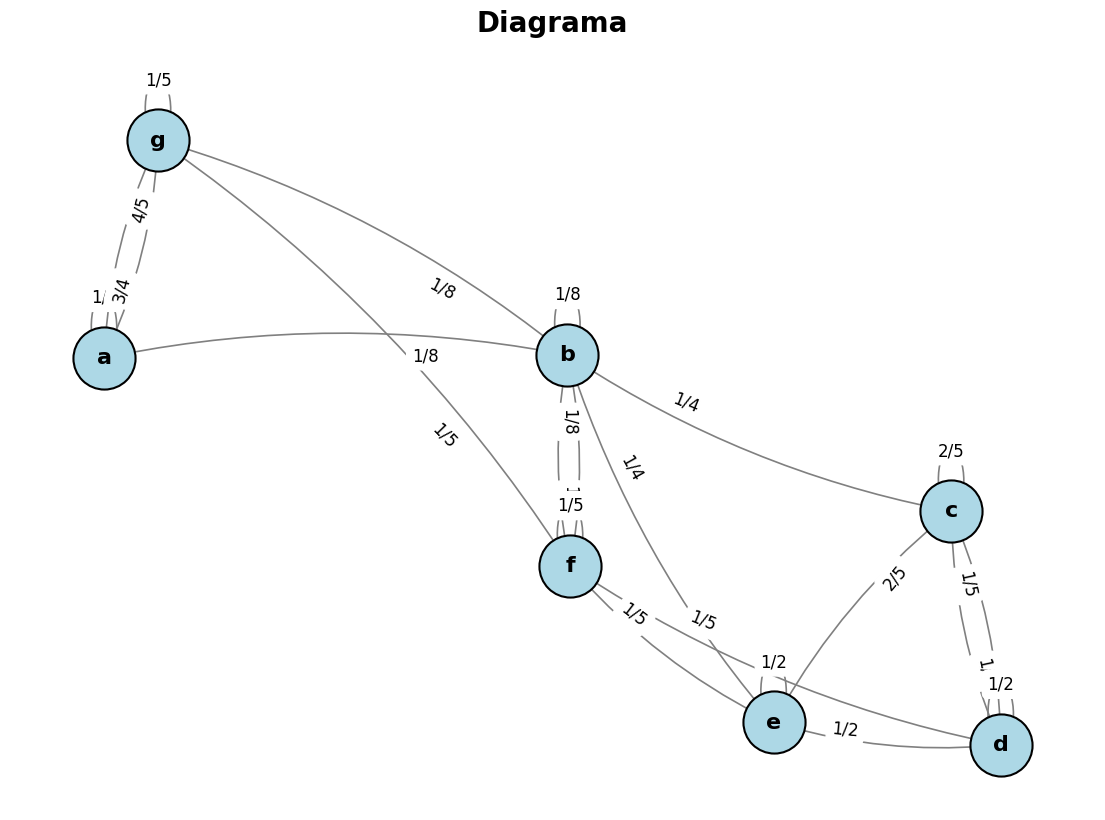

In [56]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, k=0.5, iterations=50)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=16, font_family='sans-serif', font_weight='bold')


edges_to_draw = []
loops_to_draw = []
for u, v in G.edges():
    if u == v:
        loops_to_draw.append((u, v))
    else:
        edges_to_draw.append((u, v))

nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw,
                       connectionstyle="arc3,rad=0.1",
                       arrowsize=25, edge_color='gray', width=1.2)

nx.draw_networkx_edges(G, pos, edgelist=loops_to_draw,
                       connectionstyle="arc3,rad=1.0",
                       arrowsize=25, edge_color='gray', width=1.2)
edge_labels = {}
for u, v, d in G.edges(data=True):
    weight = d['weight']
    if weight.q == 1:
        label = str(weight.p)
    else:
        label = f"{weight.p}/{weight.q}"
    edge_labels[(u, v)] = label


nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.3)

plt.axis('off')
plt.title( "Diagrama",fontsize=20, fontweight='bold')
plt.show()

**De lo anterior, obtuvimos que la matriz no es irreducible**

**Se concluye que la matriz no tiene distribucion limite**

**3.3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices**

A partir del análisis de la cadena de Markov, se identifican los siguientes conjuntos de estados:

$$T = \{b,f\} \quad \text{(estados transitorios)}$$

$$
R_1 = \{a,g\}, \quad R_2 = \{c,d,e\} \quad \text{(clases recurrentes)}$$

Por lo tanto, el espacio de estados se puede escribir como:
$$
S = T \cup R_1 \cup R_2$$

Reordenando los estados en el siguiente orden:
$$(b, f \mid a, g \mid c, d, e)$$

la matriz de transición toma la forma canónica:

$$P =
\begin{pmatrix}
Q & R_1 & R_2 \\
0 & P_1 & 0 \\
0 & 0 & P_2
\end{pmatrix}$$



Esto es:

In [57]:
# Definimos el orden basado en el análisis: T={b,f}, R1={a,g}, R2={c,d,e}
# Índices originales: a=0, b=1, c=2, d=3, e=4, f=5, g=6
order = [1, 5, 0, 6, 2, 3, 4]

# Creamos la matriz canónica reordenando filas y columnas
P_can = P.permute_rows(order).permute_cols(order)

print("Matriz canónica (Numérica):")
import numpy as np
display(np.array(P_can).astype(float))

Matriz canónica (Numérica):


array([[0.125, 0.125, 0.125, 0.125, 0.25 , 0.   , 0.25 ],
       [0.2  , 0.2  , 0.   , 0.2  , 0.   , 0.2  , 0.2  ],
       [0.   , 0.   , 0.25 , 0.75 , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.8  , 0.2  , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.4  , 0.2  , 0.4  ],
       [0.   , 0.   , 0.   , 0.   , 0.5  , 0.5  , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.5  , 0.5  ]])

O de otra forma la matriz canonica en fracciones:

\begin{pmatrix}
\frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} \\
\frac{1}{5} & \frac{1}{5} & 0 & \frac{1}{5} & 0 & \frac{1}{5} & \frac{1}{5} \\
0 & 0 & \frac{1}{4} & \frac{3}{4} & 0 & 0 & 0 \\
0 & 0 & \frac{4}{5} & \frac{1}{5} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{pmatrix}

**Determinemos el límite de la potencia n-esima**

**Distribucion estacionaria:**

In [58]:
def distribucion_estacionaria(P):
    n = P.shape[0]

    # Resolver: (P^T - I)π = 0 con suma π = 1
    A = P.T - np.eye(n)

    # Reemplazamos una ecuación por la normalización
    A[-1] = np.ones(n)
    b = np.zeros(n)
    b[-1] = 1

    pi = np.linalg.solve(A, b)
    return pi

# MATRICES
P1 = np.array([
    [1/4, 3/4],
    [4/5, 1/5]
])

P2 = np.array([
    [2/5, 1/5, 2/5],
    [1/2, 1/2, 0],
    [0,   1/2, 1/2]
])


# RESULTADOS

pi1 = distribucion_estacionaria(P1)
pi2 = distribucion_estacionaria(P2)

print("Distribución estacionaria P1 {a,g}:")
print(np.round(pi1,6))

print("\nDistribución estacionaria P2 {c,d,e}:")
print(np.round(pi2,6))

Distribución estacionaria P1 {a,g}:
[0.516129 0.483871]

Distribución estacionaria P2 {c,d,e}:
[0.333333 0.4      0.266667]


**LIMITE DE $P^N$**

In [59]:
P_float = np.array(P, dtype=float)
Pn = np.linalg.matrix_power(P_float, 100)

print("\nLímite aproximado P^n:")
print(np.round(Pn,4))


Límite aproximado P^n:
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]


**CONCLUSION:**

*El cálculo de $P^N$
 confirma que cada submatriz recurrente converge a su propia distribución estacionaria.
Las filas correspondientes a estados transitorios convergen a combinaciones de estas distribuciones, dependiendo de las probabilidades de absorción.*

FINALMENTE:\
**Escriba un programa que encuentre la descomposición canónica de una matriz dada.**


In [60]:
import numpy as np
import networkx as nx

def descomposicion_canonica(P):
    n = len(P)

    # Construir grafo
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i,j] > 0:
                G.add_edge(i, j)

    # Clases de comunicación
    scc = list(nx.strongly_connected_components(G))

    transitorios = []
    recurrentes = []


    # Clasificar estados
    for comp in scc:
        cerrado = True
        for i in comp:
            for j in range(n):
                if j not in comp and P[i,j] > 0:
                    cerrado = False
        if cerrado:
            recurrentes.append(list(comp))
        else:
            transitorios.extend(comp)


    # Orden canónico
    orden = list(transitorios)
    for r in recurrentes:
        orden.extend(r)

    P_can = P[np.ix_(orden, orden)]


    print("Estados transitorios:", transitorios)
    print("Clases recurrentes:", recurrentes)
    print("\nOrden canónico:", orden)

    print("\nMatriz en forma canónica:\n")
    print(np.round(P_can,4))

    return P_can, transitorios, recurrentes


# EJEMPLO (tu matriz)
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

P_can, T, R = descomposicion_canonica(P)

Estados transitorios: [1, 5]
Clases recurrentes: [[0, 6], [2, 3, 4]]

Orden canónico: [1, 5, 0, 6, 2, 3, 4]

Matriz en forma canónica:

[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]
